# Exploración Inicial de los Datos (Exploratory Data Analysis - EDA)


In [1]:
# imports
import pandas as pd


# graficos
import matplotlib.pyplot as plt 

____
# CREAR DF

In [2]:
# Crear dataframe + read csv
df_marketing = pd.read_csv("../Data/BANK_marketing_eda.csv")

print(f"Registros: {len(df_marketing)}")
print(f"Columnas: {df_marketing.shape[1]}")
print("\nTipos de datos:")
print(df_marketing.dtypes)


Registros: 10642
Columnas: 18

Tipos de datos:
id             int64
age          float64
job              str
marital          str
education        str
default          str
balance        int64
housing          str
loan             str
contact          str
day            int64
month            str
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome         str
deposit          str
dtype: object


In [3]:
display(df_marketing)

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10637,10638,33.0,technician,married,secondary,no,218,yes,yes,telephone,2,mar,169,4,-1,0,unknown,no
10638,10639,42.0,management,single,tertiary,no,1146,yes,no,unknown,15,may,98,2,-1,0,unknown,no
10639,10640,31.0,unemployed,single,unknown,no,167,no,no,cellular,20,nov,316,1,-1,0,unknown,no
10640,10641,30.0,blue-collar,single,secondary,yes,447,no,no,cellular,19,nov,426,2,189,6,failure,no


____
# RESUMEN ESTADÍSTICO

.describe // .value_counts // .info 

In [4]:
# Resumen estadístico ### INFO
display(df_marketing.info())

<class 'pandas.DataFrame'>
RangeIndex: 10642 entries, 0 to 10641
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         10642 non-null  int64  
 1   age        10633 non-null  float64
 2   job        10642 non-null  str    
 3   marital    10637 non-null  str    
 4   education  10635 non-null  str    
 5   default    10642 non-null  str    
 6   balance    10642 non-null  int64  
 7   housing    10642 non-null  str    
 8   loan       10642 non-null  str    
 9   contact    10642 non-null  str    
 10  day        10642 non-null  int64  
 11  month      10642 non-null  str    
 12  duration   10642 non-null  int64  
 13  campaign   10642 non-null  int64  
 14  pdays      10642 non-null  int64  
 15  previous   10642 non-null  int64  
 16  poutcome   10642 non-null  str    
 17  deposit    10642 non-null  str    
dtypes: float64(1), int64(7), str(10)
memory usage: 1.5 MB


None

In [5]:
#  Valores nulos por columna
nulos_marketing = df_marketing.isnull().sum()
nulos_marketing = nulos_marketing[nulos_marketing > 0]


print(nulos_marketing if not nulos_marketing.empty else "Sin valores nulos.")

age          9
marital      5
education    7
dtype: int64


In [6]:
# Detección de 'unknown' (cualquier variación)
print("\nVALORES 'UNKNOWN':")
cols_categoricas = df_marketing.select_dtypes(include='object').columns
for col in cols_categoricas:
    count = df_marketing[col].str.lower().str.strip().eq('unknown').sum() #contar cantidad de unknown
    if count > 0:
        print(f"  {col}: {count}")


VALORES 'UNKNOWN':
  job: 68
  education: 473
  contact: 2196
  poutcome: 7885


C:\Users\raari\AppData\Local\Temp\ipykernel_42316\3027018577.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_categoricas = df_marketing.select_dtypes(include='object').columns


In [7]:
# Resumen estadístico ### VALUE COUNTS
display(df_marketing.value_counts())

id     age   job          marital  education  default  balance  housing  loan  contact    day  month  duration  campaign  pdays  previous  poutcome  deposit
1      59.0  admin.       married  secondary  no       2343     yes      no    unknown    5    may    1042      1         -1     0         unknown   yes        1
2      56.0  admin.       married  secondary  no       45       no       no    unknown    5    may    1467      1         -1     0         unknown   yes        1
3      41.0  technician   married  secondary  no       1270     yes      no    unknown    5    may    1389      1         -1     0         unknown   yes        1
4      55.0  services     married  secondary  no       2476     yes      no    unknown    5    may    579       1         -1     0         unknown   yes        1
5      54.0  admin.       married  tertiary   no       184      no       no    unknown    5    may    673       2         -1     0         unknown   yes        1
                                 

In [8]:
# Resumen estadístico ### DESCRIBE
display(df_marketing.describe())

,id,age,balance,day,duration,campaign,pdays,previous
count,10642.000000,10633.000000,10642.000000,10642.000000,10642.000000,10642.000000,10642.000000,10642.000000
mean,5321.500000,41.252610,1536.614828,15.645461,378.693197,2.496147,52.073670,0.851344
std,3072.225117,12.003015,3223.419300,8.432874,351.180910,2.694660,109.208889,2.321755
min,1.000000,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,2661.250000,32.000000,127.000000,8.000000,141.000000,1.000000,-1.000000,0.000000
50%,5321.500000,39.000000,558.000000,15.000000,260.000000,2.000000,-1.000000,0.000000
75%,7981.750000,49.000000,1728.750000,22.000000,510.000000,3.000000,57.750000,1.000000
max,10642.000000,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [9]:
# Min/Max de variables numéricas (primer vistazo de valores atípicos)

display(df_marketing.select_dtypes(include='number').agg(['min', 'max'])) #seleccion por datatype NUMERO

,id,age,balance,day,duration,campaign,pdays,previous
min,1,18.0,-6847,1,2,1,-1,0
max,10642,95.0,81204,31,3881,63,854,58


______
# VISUALIZACIONES INICIALES

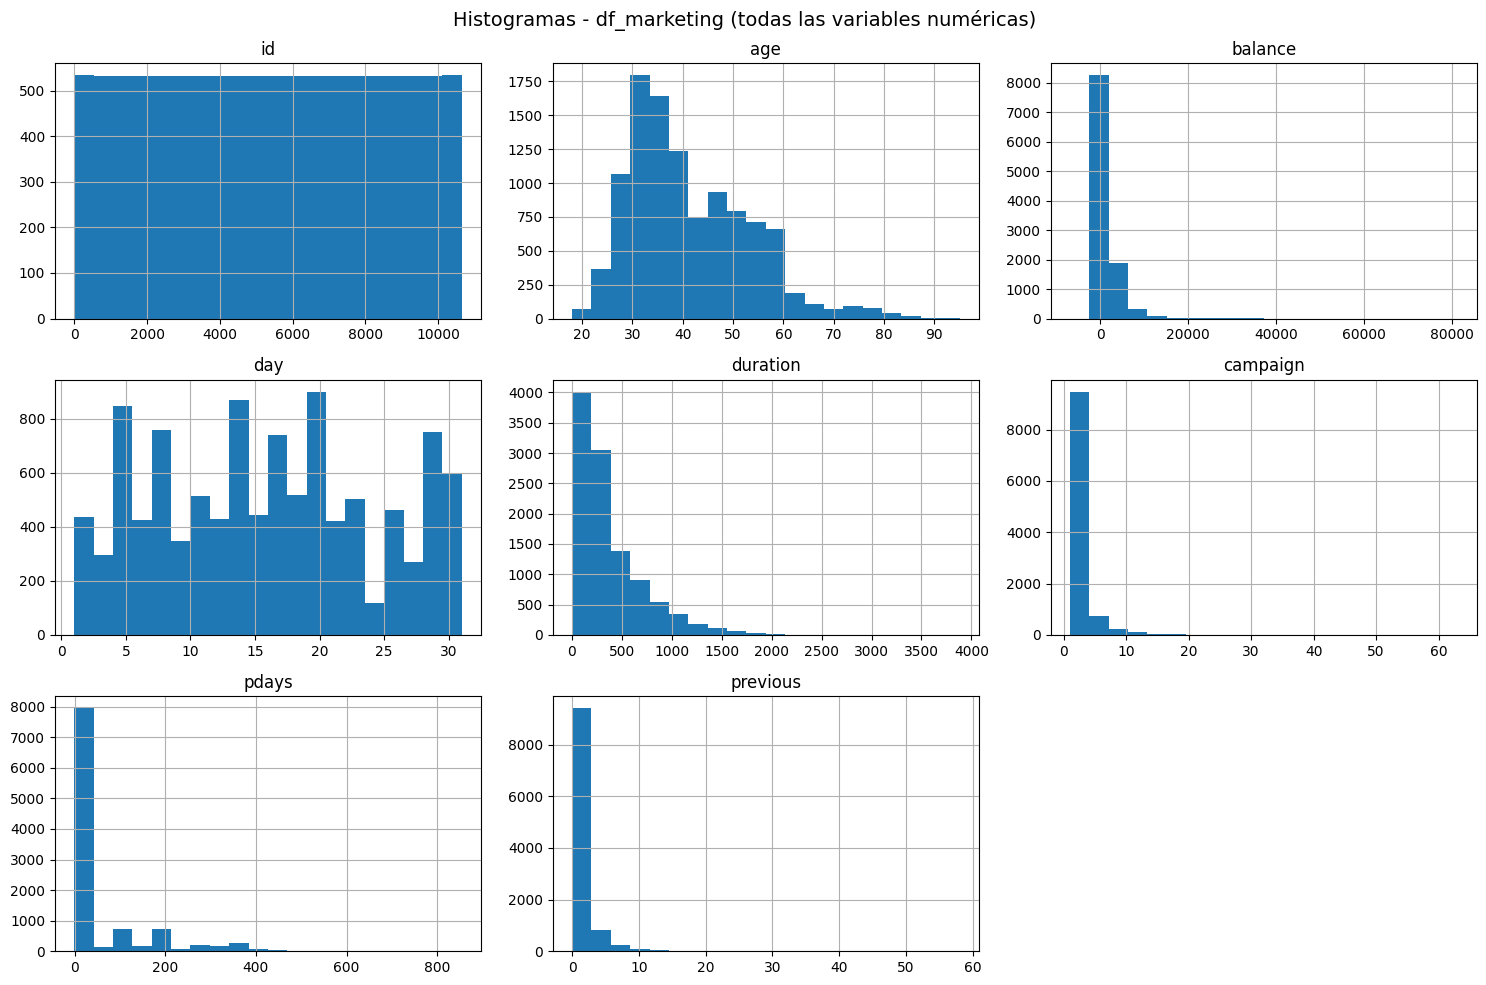

In [10]:
# Variables numéricas
cols_numericas = df_marketing.select_dtypes(include='number').columns #seleccion por datatype NUMERO

# 1. Todas las variables numéricas en un solo bloque
df_marketing[cols_numericas].hist(bins=20, figsize=(15, 10))
plt.suptitle("Histogramas - df_marketing (todas las variables numéricas)", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# Value counts por columna categórica
cols_categoricas = df_marketing.select_dtypes(include='object').columns

for col in cols_categoricas:
    print(f"\n{col}:")
    print(df_marketing[col].value_counts())


job:
job
management       2447
blue-collar      1830
technician       1737
admin.           1279
services          881
retired           755
self-employed     388
student           354
unemployed        338
entrepreneur      308
housemaid         257
unknown            68
Name: count, dtype: int64

marital:
marital
married     6030
single      3374
divorced    1233
Name: count, dtype: int64

education:
education
secondary    5216
tertiary     3527
primary      1419
unknown       473
Name: count, dtype: int64

default:
default
no     10487
yes      155
Name: count, dtype: int64

housing:
housing
no     5660
yes    4982
Name: count, dtype: int64

loan:
loan
no     9270
yes    1372
Name: count, dtype: int64

contact:
contact
cellular     7707
unknown      2196
telephone     739
Name: count, dtype: int64

month:
month
may    2646
aug    1450
jul    1429
jun    1174
nov     898
apr     888
feb     746
oct     387
jan     327
sep     314
mar     274
dec     109
Name: count, dtype: int64

po

C:\Users\raari\AppData\Local\Temp\ipykernel_42316\3785547276.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_categoricas = df_marketing.select_dtypes(include='object').columns


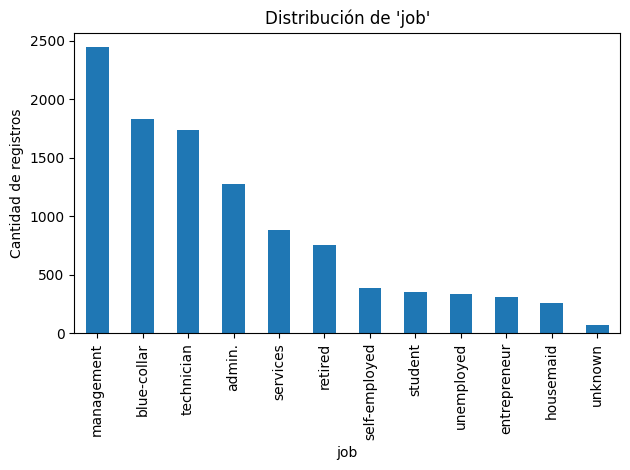

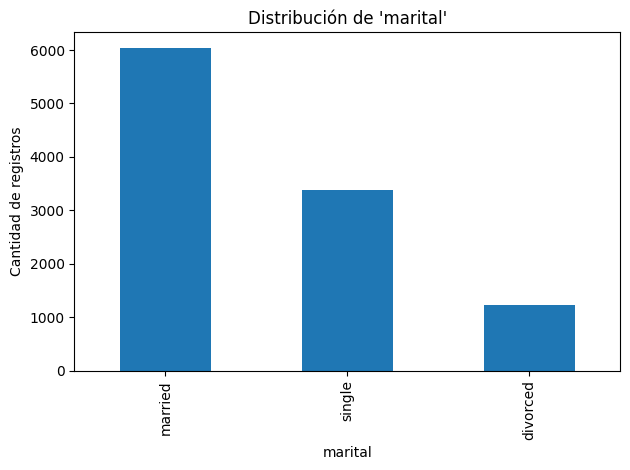

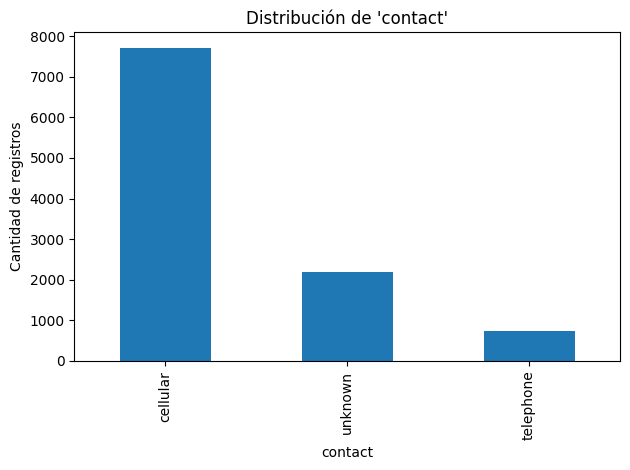

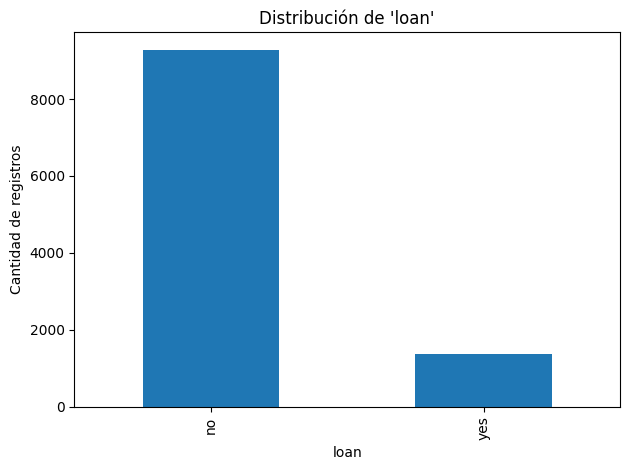

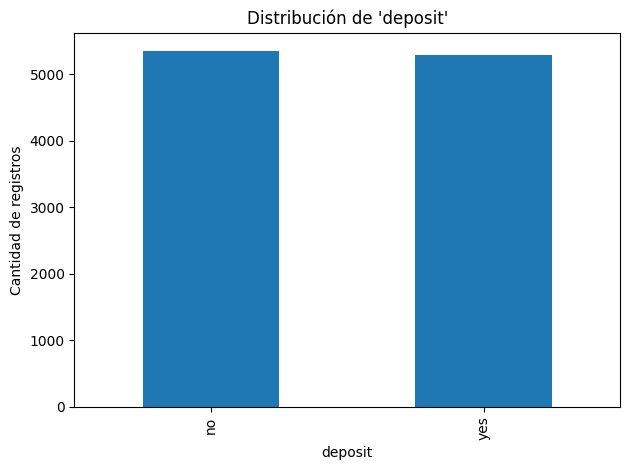

In [12]:
# Distribución de variables categóricas

categoricas = ['job', 'marital', 'contact', 'loan', 'deposit']

for col in categoricas:
    df_marketing[col].value_counts().plot.bar()
    plt.title(f"Distribución de '{col}'")
    plt.xlabel(col)
    plt.ylabel("Cantidad de registros")
    plt.tight_layout()
    plt.show()

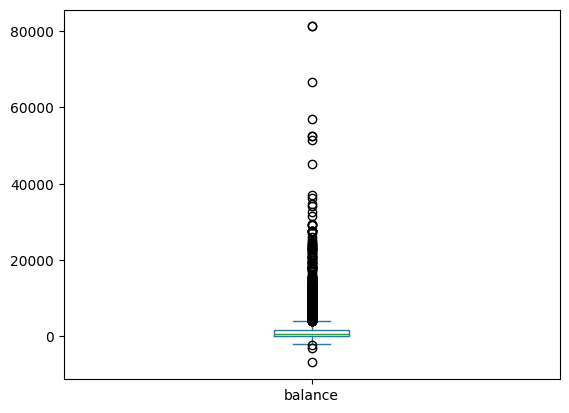

In [13]:
# balance ## BOX PLOT

df_marketing['balance'].plot.box();

Aquí con BALANCE hay algo raro
____
